# Etapa 2 — Modelado con Validación Segura

**Proyecto Integrador de Aprendizaje Automático — Predicción de Falla Cardíaca**

Este notebook (sección 10.12.7 de las notas) construye el modelo final:

1. División de los datos **antes** de cualquier escalado/encoding.
2. `Pipeline` (preprocesamiento + modelo) + `GridSearchCV` para el modelo ganador de la Etapa 1.
3. Evaluación completa: matriz de confusión, curva ROC y AUC.
4. Exportación del pipeline final a `../app/model.joblib` para servirlo con FastAPI (Etapa 3).
5. Reporte de deriva de datos (*data drift*) con **Evidently** (Etapa 6).


## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

import joblib

RANDOM_STATE = 42


## 2. Carga de datos\n\nMismo dataset local (`data/heart.csv`) y columna objetivo (`HeartDisease`) que en `1_model_leakage_demo.ipynb`.\n

In [2]:
import pandas as pd

df = pd.read_csv("../data/heart.csv")

TARGET_COL = "HeartDisease"
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

CATEGORICAL_COLS = [c for c in ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"] if c in X.columns]
NUMERIC_COLS = [c for c in X.columns if c not in CATEGORICAL_COLS]

print("Orden exacto de columnas de entrada esperado por el Pipeline (para la API):")
print(list(X.columns))


Orden exacto de columnas de entrada esperado por el Pipeline (para la API):
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']


## 3. División train/test antes de preprocesar

Requisito explícito de las notas: **la división debe hacerse antes del preprocesamiento**, para que
ningún dato de prueba influya en el ajuste del escalador/encoder.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), NUMERIC_COLS),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLS),
    ]
)


## 4. Pipeline final + GridSearchCV

Se usa `GradientBoostingClassifier`, el modelo ganador típico de la comparación en
`1_model_leakage_demo.ipynb` (ajusta este bloque si en tu ejecución otro modelo obtuvo mejor AUC).


In [4]:
pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE)),
])

param_grid = {
    "clf__n_estimators": [100, 200, 300],
    "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "clf__max_depth": [2, 3, 4],
}

grid = GridSearchCV(pipe, param_grid=param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print(f"Mejor AUC (validación cruzada): {grid.best_score_:.3f}")


Mejores parámetros: {'clf__learning_rate': 0.01, 'clf__max_depth': 2, 'clf__n_estimators': 300}
Mejor AUC (validación cruzada): 0.924


## 5. Evaluación en el set de prueba

In [5]:
y_pred = grid.predict(X_test)
y_scores = grid.predict_proba(X_test)[:, 1]

auc_test = roc_auc_score(y_test, y_scores)
acc_test = accuracy_score(y_test, y_pred)

print(f"AUC (test):      {auc_test:.3f}")
print(f"Accuracy (test): {acc_test:.3f}")


AUC (test):      0.924
Accuracy (test): 0.880


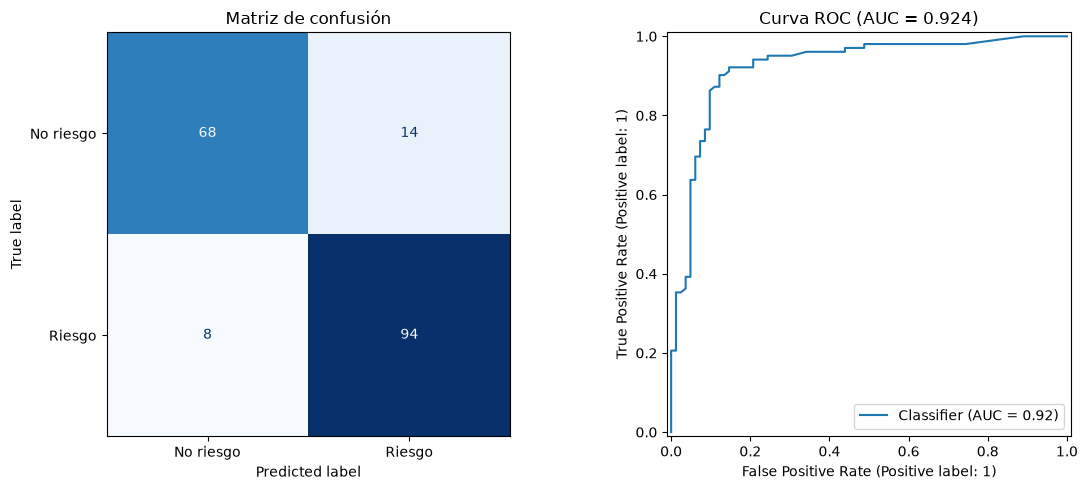

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No riesgo", "Riesgo"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Matriz de confusión")

RocCurveDisplay.from_predictions(y_test, y_scores, ax=axes[1])
axes[1].set_title(f"Curva ROC (AUC = {auc_test:.3f})")

plt.tight_layout()
plt.show()


## 6. Exportación del modelo final

Se serializa el `Pipeline` completo (preprocesamiento + modelo) para que la API (Etapa 3) pueda
transformar y predecir directamente sobre datos crudos.

> **Importante para `app/api.py`:** el pipeline serializado espera un vector de features **en el mismo
> orden** que `X_train.columns` (impreso arriba, en la sección 2). La API recibe `features: list` sin
> nombres de columna, así que el orden debe respetarse al construir la petición.


In [7]:
joblib.dump(grid.best_estimator_, "../app/model.joblib")
print("Modelo exportado a ../app/model.joblib")
print("Orden de columnas esperado:", list(X_train.columns))


Modelo exportado a ../app/model.joblib
Orden de columnas esperado: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']


## 7. Monitoreo de deriva de datos (Evidently)

Etapa 6 de las notas: se genera un reporte de *data drift* comparando la distribución de
`X_train` (referencia) contra `X_test` (actual). En producción, `X_test` se reemplazaría por lotes
reales de datos recibidos por la API.

> `pip install evidently`
>
> **Nota de API:** las notas del curso muestran la API antigua de Evidently
> (`evidently.report.Report` + `evidently.metric_preset.DataDriftPreset`, disponible hasta la serie
> 0.4.x). La versión instalada con `pip install evidently` hoy (0.7.x) reorganizó el paquete; el
> import y uso correcto y equivalente en la versión actual es `evidently.Report` +
> `evidently.presets.DataDriftPreset`, usado abajo.


In [8]:
from evidently import Report
from evidently.presets import DataDriftPreset

report = Report(metrics=[DataDriftPreset()])
snapshot = report.run(
    reference_data=X_train.reset_index(drop=True),
    current_data=X_test.reset_index(drop=True),
)
snapshot.save_html("../drift_report.html")
print("Reporte de drift guardado en ../drift_report.html")


Reporte de drift guardado en ../drift_report.html
